<a href="https://colab.research.google.com/github/CyberSnorlax/ETF-Markowitz-Portfolio-Optimization/blob/Alpha2/Alpha2_ROE_DE_next_month.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part 1: Data Collection and Feature Engineering


In [24]:
#%% [code]
import yfinance as yf
import pandas as pd
import numpy as np
import os
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
import joblib
import datetime

# File paths and date ranges
price_data_path = 'price_data.csv'
features_path = 'features_data.csv'
scaler_path = 'scaler.joblib'
sp500_index_path = 'sp500_index.csv'
# For saving scaled datasets (if needed)
X_train_scaled_path = 'X_train_scaled.joblib'
X_val_scaled_path   = 'X_val_scaled.joblib'
X_test_scaled_path  = 'X_test_scaled.joblib'
y_train_path = 'y_train.joblib'
y_val_path   = 'y_val.joblib'
y_test_path  = 'y_test.joblib'

# Define the periods for ML training
train_start = '2019-01-01'
train_end   = '2023-12-31'
val_start   = '2023-12-31'  # Overlap end/beginning can be adjusted as needed
val_end     = '2024-12-31'
test_start  = '2024-06-01'
test_end    = '2025-03-31'
data_start  = '2018-01-01'  # For technical indicator warm-up

# Function to fetch the list of S&P500 tickers from Wikipedia
def fetch_sp500_tickers():
    print("Fetching S&P500 tickers...")
    tickers = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]['Symbol'].tolist()
    # Adjust ticker symbols if needed (e.g. BRK.B -> BRK-B)
    tickers = [t.replace('BRK.B', 'BRK-B').replace('BF.B', 'BF-B') for t in tickers]
    return tickers

# Function to fetch historical price data for all tickers
def fetch_price_data(tickers):
    if os.path.exists(price_data_path):
        print("Loading existing price data...")
        return pd.read_csv(price_data_path, index_col='Date', parse_dates=True)

    print("Downloading price data from yfinance...")
    data = yf.download(tickers, start=data_start, end=test_end, auto_adjust=True, threads=True)['Close']
    # Drop tickers with too many missing values
    data = data.dropna(axis=1, thresh=int(0.9 * len(data)))
    data.to_csv(price_data_path)
    print(f"Saved price data for {len(data.columns)} tickers to {price_data_path}")
    return data

# Function to fetch the S&P500 index (for regime detection or benchmark)
def fetch_sp500_index():
    if os.path.exists(sp500_index_path):
        print("Loading existing S&P500 index data...")
        return pd.read_csv(sp500_index_path, index_col='Date', parse_dates=True)

    print("Downloading S&P500 index data from yfinance...")
    sp500 = yf.download('^GSPC', start=data_start, end=test_end, auto_adjust=True)['Close']
    sp500.to_csv(sp500_index_path)
    print(f"Saved S&P500 index data to {sp500_index_path}")
    return sp500

# Function to retrieve fundamental data (ROE and Debt/Equity) for a ticker
def get_fundamentals(ticker):
    try:
        t = yf.Ticker(ticker)
        info = t.info
        # ROE is often reported as a decimal (e.g., 0.20 for 20%)
        roe = info.get('returnOnEquity', None)
        # Debt-to-equity might be provided as a string or float (assume float)
        debt_to_equity = info.get('debtToEquity', None)
        return roe, debt_to_equity
    except Exception as e:
        print(f"Error fetching fundamentals for {ticker}: {e}")
        return None, None

# Function to calculate technical indicators (here we add a 200-day SMA)
def calculate_indicators(close):
    sma20 = close.rolling(20).mean()
    sma50 = close.rolling(50).mean()
    sma200 = close.rolling(200).mean()
    sma_ratio = sma20 / sma50 - 1
    # Additional indicators
    delta = close.diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = -delta.where(delta < 0, 0).rolling(14).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    ema12 = close.ewm(span=12).mean()
    ema26 = close.ewm(span=26).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9).mean()
    macd_hist = macd - signal
    volatility = close.pct_change().rolling(30).std() * np.sqrt(252)
    std20 = close.rolling(20).std()
    bb_width = (sma20 + 2 * std20 - (sma20 - 2 * std20)) / sma20

    df = pd.DataFrame({
        'sma_ratio': sma_ratio,
        'rsi': rsi,
        'macd_hist': macd_hist,
        'volatility': volatility,
        'bb_width': bb_width,
        'sma200': sma200
    })
    return df

# Function to calculate ARIMA-based features for stock data
def calculate_arima_features(close, periods=[5, 10, 21]):
    """
    Generate ARIMA-based prediction features for a stock's close price

    Parameters:
    close (pd.Series): Time series of close prices
    periods (list): List of forward-looking periods to forecast

    Returns:
    pd.DataFrame: DataFrame containing ARIMA prediction features
    """
    import warnings
    warnings.filterwarnings("ignore")

    # Container for ARIMA features
    arima_features = pd.DataFrame(index=close.index)

    # Prepare log returns for better ARIMA performance
    log_close = np.log(close)
    log_returns = log_close.diff().dropna()

    try:
        # Fit ARIMA model on log returns
        # Using simple ARIMA(1,0,1) for speed and stability
        model = ARIMA(log_returns, order=(1, 0, 1))
        model_fit = model.fit()

        # Generate forecasts for different periods
        for period in periods:
            forecast = model_fit.forecast(steps=period)

            # Calculate cumulative expected return over the forecast period
            cumulative_forecast = forecast.sum()

            # Convert back to price prediction (exp since we used log returns)
            current_log_price = log_close.iloc[-1]
            predicted_log_price = current_log_price + cumulative_forecast
            predicted_price = np.exp(predicted_log_price)

            # Calculate predicted return
            current_price = close.iloc[-1]
            predicted_return = (predicted_price / current_price) - 1

            # Add as feature
            arima_features[f'arima_pred_{period}d'] = np.nan
            arima_features.iloc[-1, arima_features.columns.get_loc(f'arima_pred_{period}d')] = predicted_return

            # Fill backward with rolling method to avoid lookahead bias
            arima_features[f'arima_pred_{period}d'] = arima_features[f'arima_pred_{period}d'].fillna(method='bfill')

        # Add ARIMA model parameters as features
        params = model_fit.params
        arima_features['arima_ar1'] = params.get('ar.L1', 0)
        arima_features['arima_ma1'] = params.get('ma.L1', 0)
        arima_features['arima_const'] = params.get('const', 0)

        # Add model quality metrics
        arima_features['arima_aic'] = model_fit.aic
        arima_features['arima_volatility'] = log_returns.std() * np.sqrt(252)  # Annualized

    except Exception as e:
        # Handle errors gracefully
        print(f"ARIMA model error: {e}")
        # Fill with zeros if model fails
        for period in periods:
            arima_features[f'arima_pred_{period}d'] = 0
        arima_features['arima_ar1'] = 0
        arima_features['arima_ma1'] = 0
        arima_features['arima_const'] = 0
        arima_features['arima_aic'] = 0
        arima_features['arima_volatility'] = log_returns.std() * np.sqrt(252) if not log_returns.empty else 0

    return arima_features

# Main function to prepare the feature dataset for ML training
def prepare_data(price_data, sp500_index, tickers):
    features_list = []

    skipped_tickers = {
    'insufficient_data': [],
    'missing_fundamentals': [],
    'insufficient_rows': [],
    'error': []}

    # For regime or market state (optional)
    regime = (sp500_index.rolling(200).mean() > sp500_index).astype(int)  # 1 = bear, 0 = bull

    for ticker in tickers:
        print(f"Processing {ticker} ...")
        try:
            close = price_data[ticker].dropna()
            if len(close) < 252:
                skipped_tickers['insufficient_data'].append(ticker)
                print(f"Skipping {ticker}: insufficient data")
                continue

            # Compute technical indicators
            tech_df = calculate_indicators(close)

            # Compute ARIMA features
            arima_df = calculate_arima_features(close, periods=[5, 10, 21])

            # Merge technical and ARIMA features
            features_df = pd.concat([tech_df, arima_df], axis=1)
            # Remove duplicate columns if any
            features_df = features_df.loc[:,~features_df.columns.duplicated()]

            # Get fundamental data
            roe, debt_to_equity = get_fundamentals(ticker)
            if roe is None or debt_to_equity is None:
                skipped_tickers['missing_fundamentals'].append(ticker)
                print(f"Skipping {ticker}: missing fundamental data")
                continue

            # For demonstration, assume roe is in decimal form (e.g., 0.25 for 25%) and debt_to_equity as float
            features_df['roe'] = roe
            features_df['debt_to_equity'] = debt_to_equity

            # Compute a binary flag: is price above 200-day SMA?
            features_df['above_sma200'] = (close > features_df['sma200']).astype(int)

            # Fundamental Filters as additional features (you can also use these to filter later)
            # For long candidates: price > sma200, roe > 0.20, debt_to_equity < 1.
            features_df['fund_long'] = ((close > features_df['sma200']) & (roe > 0.20) & (debt_to_equity < 1)).astype(int)
            # For short candidates: price < sma200, roe < 0.10, debt_to_equity > 2.
            features_df['fund_short'] = ((close < features_df['sma200']) & (roe < 0.10) & (debt_to_equity > 2)).astype(int)

            # Add ticker and date information
            features_df['ticker'] = ticker
            features_df['date'] = close.index

            # Calculate forward return (using 21 trading days ~ 1 month)
            features_df['future_price'] = close.shift(-21)
            features_df['fwd_return'] = (features_df['future_price'] / close) - 1

            # Drop rows with missing forward return (and ensure indicator columns are not NA)
            feature_cols = list(features_df.columns.difference(['ticker', 'date', 'future_price', 'fwd_return']))
            features_df = features_df.dropna(subset=['fwd_return'] + feature_cols)
            if len(features_df) < 50:
                skipped_tickers['insufficient_rows'].append(ticker)
                print(f"Skipping {ticker}: insufficient rows after cleaning")
                continue

            # Create labels based on forward return quantiles
            # Here we use three classes: -1 (poor return), 0 (neutral), 1 (good return)
            features_df['label'] = pd.qcut(features_df['fwd_return'], q=[0, 0.25, 0.75, 1],
                                       labels=[-1, 0, 1], duplicates='drop').astype(int)

            # Include a market regime feature (align using ffill)
            features_df['regime'] = regime.reindex(features_df.index, method='ffill').fillna(0)

            features_list.append(features_df)
        except Exception as e:
            skipped_tickers['error'].append(ticker)
            print(f"Error processing {ticker}: {e}")

    if not features_list:
        raise ValueError("No valid feature data was generated.")

    all_features = pd.concat(features_list, ignore_index=True)
    all_features.to_csv(features_path, index=False)
    print(f"Saved features data to {features_path}")
    print(f"Processed a total of {len(features_list)} stocks with {len(all_features)} data points and {len(all_features.columns) - 4} features")
    print(f"Skipped {(skipped_tickers)}")


    return all_features

# --- Main execution for Part 1 ---
tickers = fetch_sp500_tickers()
price_data = fetch_price_data(tickers)
sp500_index = fetch_sp500_index()
features_df = prepare_data(price_data, sp500_index, tickers)

Fetching S&P500 tickers...
Loading existing price data...
Loading existing S&P500 index data...
Processing MMM ...
Processing AOS ...
Processing ABT ...
Skipping ABT: missing fundamental data
Processing ABBV ...
Processing ACN ...
Processing ADBE ...
Processing AMD ...
Processing AES ...
Processing AFL ...
Processing A ...
Processing APD ...
Processing ABNB ...
Error processing ABNB: 'ABNB'
Processing AKAM ...
Processing ALB ...
Processing ARE ...
Processing ALGN ...
Processing ALLE ...
Processing LNT ...
Processing ALL ...
Processing GOOGL ...
Processing GOOG ...
Processing MO ...
Skipping MO: missing fundamental data
Processing AMZN ...
Processing AMCR ...
Processing AEE ...
Processing AEP ...
Processing AXP ...
Processing AIG ...
Processing AMT ...
Processing AWK ...
Processing AMP ...
Processing AME ...
Processing AMGN ...
Processing APH ...
Processing ADI ...
Processing ANSS ...
Processing AON ...
Processing APA ...
Processing APO ...
Processing AAPL ...
Processing AMAT ...
Proces

Part 2: Model Training and Prediction Aggregation

In [25]:
#%% [code]
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

def train_models(features_df):
    # Define feature columns (updated to include ARIMA features)
    base_cols = ['sma_ratio', 'rsi', 'macd_hist', 'volatility', 'bb_width', 'roe', 'debt_to_equity',
                'above_sma200', 'fund_long', 'fund_short', 'regime']

    # Find ARIMA feature columns (any column starting with 'arima_')
    arima_cols = [col for col in features_df.columns if col.startswith('arima_')]

    # Combine base features with ARIMA features
    X_cols = base_cols + arima_cols

    print(f"Training models with {len(X_cols)} features, including {len(arima_cols)} ARIMA features")
    print("ARIMA features:", arima_cols)

    # Convert date column to datetime
    features_df['date'] = pd.to_datetime(features_df['date'])

    # Split the data into Train, Validation, and Test sets based on date
    train_df = features_df[(features_df['date'] >= train_start) & (features_df['date'] <= train_end)]
    val_df   = features_df[(features_df['date'] > train_end) & (features_df['date'] <= val_end)]
    test_df  = features_df[(features_df['date'] > val_end) & (features_df['date'] <= test_end)]

    X_train, y_train = train_df[X_cols], train_df['label']
    X_val, y_val     = val_df[X_cols], val_df['label']
    X_test, y_test   = test_df[X_cols], test_df['label']

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)
    X_test_scaled  = scaler.transform(X_test)

    joblib.dump(scaler, scaler_path)
    joblib.dump(X_train_scaled, X_train_scaled_path)
    joblib.dump(X_val_scaled, X_val_scaled_path)
    joblib.dump(X_test_scaled, X_test_scaled_path)
    joblib.dump(y_train, y_train_path)
    joblib.dump(y_val, y_val_path)
    joblib.dump(y_test, y_test_path)
    print("Saved scaled data and labels.")

    # Train Logistic Regression
    lr = LogisticRegression(multi_class='multinomial', random_state=42, max_iter=1000)  # Increased max_iter for convergence
    lr.fit(X_train_scaled, y_train)
    lr_val_acc = accuracy_score(y_val, lr.predict(X_val_scaled))
    print(f"Logistic Regression Validation Accuracy: {lr_val_acc:.4f}")
    joblib.dump(lr, 'lr_model.joblib')

    # Train KNN
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    knn_val_acc = accuracy_score(y_val, knn.predict(X_val_scaled))
    print(f"KNN Validation Accuracy: {knn_val_acc:.4f}")
    joblib.dump(knn, 'knn_model.joblib')

    # Prepare sequences for LSTM
    sequence_length = 20
    def create_sequences(X, y, seq_len):
        Xs, ys = [], []
        for i in range(len(X) - seq_len):
            Xs.append(X[i:(i+seq_len)])
            ys.append(y.iloc[i+seq_len])
        return np.array(Xs), np.array(ys)

    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, sequence_length)
    X_val_seq, y_val_seq     = create_sequences(X_val_scaled, y_val, sequence_length)
    X_test_seq, y_test_seq   = create_sequences(X_test_scaled, y_test, sequence_length)

    # One-hot encode the labels for LSTM (3 classes: -1, 0, 1)
    y_train_seq = pd.get_dummies(y_train_seq).values
    y_val_seq   = pd.get_dummies(y_val_seq).values
    y_test_seq  = pd.get_dummies(y_test_seq).values

    # Build LSTM model
    lstm = Sequential([
        LSTM(50, return_sequences=True, input_shape=(sequence_length, len(X_cols))),
        Dropout(0.2),
        LSTM(50),
        Dropout(0.2),
        Dense(3, activation='softmax')
    ])
    lstm.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    lstm.fit(X_train_seq, y_train_seq, epochs=10, batch_size=32, validation_data=(X_val_seq, y_val_seq), verbose=1)
    lstm_val_acc = lstm.evaluate(X_val_seq, y_val_seq, verbose=0)[1]
    print(f"LSTM Validation Accuracy: {lstm_val_acc:.4f}")
    lstm.save('lstm_model.h5')

    return X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test

# --- Main execution for Part 2 ---
X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test = train_models(features_df)


Training models with 19 features, including 8 ARIMA features
ARIMA features: ['arima_pred_5d', 'arima_pred_10d', 'arima_pred_21d', 'arima_ar1', 'arima_ma1', 'arima_const', 'arima_aic', 'arima_volatility']
Saved scaled data and labels.
Logistic Regression Validation Accuracy: 0.5463
KNN Validation Accuracy: 0.4140
Epoch 1/10
16825/16825 ━━━━━━━━━━━━━━━━━━━━ 249s 15ms/step - accuracy: 0.5169 - loss: 1.0057 - val_accuracy: 0.5384 - val_loss: 1.0284
Epoch 2/10
16825/16825 ━━━━━━━━━━━━━━━━━━━━ 243s 14ms/step - accuracy: 0.5418 - loss: 0.9636 - val_accuracy: 0.5286 - val_loss: 1.0350
Epoch 3/10
16825/16825 ━━━━━━━━━━━━━━━━━━━━ 241s 14ms/step - accuracy: 0.5570 - loss: 0.9370 - val_accuracy: 0.5331 - val_loss: 1.0378
Epoch 4/10
16825/16825 ━━━━━━━━━━━━━━━━━━━━ 243s 14ms/step - accuracy: 0.5672 - loss: 0.9184 - val_accuracy: 0.5293 - val_loss: 1.0447
Epoch 5/10
16825/16825 ━━━━━━━━━━━━━━━━━━━━ 241s 14ms/step - accuracy: 0.5754 - loss: 0.9032 - val_accuracy: 0.5147 - val_loss: 1.0679
Epoch 6/10

LSTM Validation Accuracy: 0.5097


In [26]:
#%% [code]
def aggregate_predictions(features_df, scaler):
    # Get base columns
    base_cols = ['sma_ratio', 'rsi', 'macd_hist', 'volatility', 'bb_width', 'roe', 'debt_to_equity',
                'above_sma200', 'fund_long', 'fund_short', 'regime']

    # Find ARIMA feature columns (any column starting with 'arima_')
    arima_cols = [col for col in features_df.columns if col.startswith('arima_')]

    # Combine base features with ARIMA features
    X_cols = base_cols + arima_cols

    print(f"Making predictions with {len(X_cols)} features, including {len(arima_cols)} ARIMA features")

    X_full = features_df[X_cols]
    X_full_scaled = scaler.transform(X_full)

    # Load trained models
    lr = joblib.load('lr_model.joblib')
    knn = joblib.load('knn_model.joblib')
    lstm = load_model('lstm_model.h5')

    # Get predictions from LR and KNN
    lr_preds = lr.predict(X_full_scaled)
    knn_preds = knn.predict(X_full_scaled)

    # For LSTM, we need to create sequences; choose a sequence length (e.g., 10)
    seq_len = 10
    def create_sequences(X, seq_len):
        Xs = []
        for i in range(len(X) - seq_len):
            Xs.append(X[i:(i+seq_len)])
        return np.array(Xs)
    X_full_seq = create_sequences(X_full_scaled, seq_len)
    lstm_preds_prob = lstm.predict(X_full_seq, verbose=0)
    lstm_preds = np.argmax(lstm_preds_prob, axis=1) - 1  # Convert from one-hot (0,1,2) to (-1,0,1)

    # Align predictions (discard the first 'seq_len' rows for LSTM)
    pred_df = features_df.iloc[seq_len:].copy()
    pred_df['lr_pred'] = lr_preds[seq_len:]
    pred_df['knn_pred'] = knn_preds[seq_len:]
    pred_df['lstm_pred'] = lstm_preds

    # Ensemble prediction: average the three predictions
    pred_df['ensemble_pred'] = pred_df[['lr_pred', 'knn_pred', 'lstm_pred']].mean(axis=1)

    # Add ARIMA predictions as a feature for interpretability
    for period in [5, 10, 21]:
        col = f'arima_pred_{period}d'
        if col in pred_df.columns:
            # Create a normalized prediction (-1 to 1 scale)
            pred_df[f'arima_{period}d_signal'] = np.where(
                pred_df[col] > 0.01, 1,  # Positive return > 1% → buy signal
                np.where(pred_df[col] < -0.01, -1, 0)  # Negative return < -1% → sell signal
            )

    # Save predictions
    pred_df.to_csv('model_predictions.csv', index=False)
    print("Saved model predictions to model_predictions.csv")
    return pred_df

# --- Aggregate predictions ---
scaler = joblib.load(scaler_path)
pred_df = aggregate_predictions(features_df, scaler)

scaler_save_path = '/content/drive/MyDrive/scaler.joblib'
joblib.dump(scaler, scaler_save_path)
print(f"Scaler saved to {scaler_save_path}")

# Save pred_df to Google Drive
predictions_save_path = '/content/drive/MyDrive/model_predictions.csv'
pred_df.to_csv(predictions_save_path, index=False)
print(f"Predictions saved to {predictions_save_path}")


Making predictions with 19 features, including 8 ARIMA features


Saved model predictions to model_predictions.csv
Scaler saved to /content/drive/MyDrive/scaler.joblib
Predictions saved to /content/drive/MyDrive/model_predictions.csv


Load Training Models

Part 3: Portfolio Construction and Backtesting

Constructing portfolio selections (Modified)...
Saved portfolio selections to portfolio_selections.csv
Backtesting portfolio (Modified)...

2024-07 Positions:
Long: ['ERIE']
Short: ['ALB', 'WDAY', 'TDY', 'LH']
2024-07 Monthly Return: 0.1808

2024-08 Positions:
Long: ['ANET', 'ERIE', 'TPL']
Short: ['MOS', 'EQT', 'EL']
2024-08 Monthly Return: 0.1103

2024-09 Positions:
Long: ['ANET', 'MPWR']
Short: ['CTRA', 'TAP', 'GPN']
2024-09 Monthly Return: 0.0465

2024-10 Positions:
Long: ['ANET', 'MPWR']
Short: ['CTRA']
2024-10 Monthly Return: -0.0855

2024-11 Positions:
Long: ['ANET', 'TPL', 'ERIE']
Short: ['INTC', 'CRL', 'ZBH', 'ALB', 'XYL']
2024-11 Monthly Return: 0.0310

2024-12 Positions:
Long: ['ERIE', 'ANET', 'TPL']
Short: ['MOS', 'PSX', 'CI', 'SWKS', 'XYL', 'ZBH']
2024-12 Monthly Return: -0.0202

2025-01 Positions:
Long: ['ANET', 'TPL']
Short: ['ALB', 'EL', 'FE']
2025-01 Monthly Return: 0.0811

2025-02 Positions:
Long: ['ANET']
Short: ['PCG', 'OXY', 'DD', 'HUM', 'ED']
2025-02 Monthly Return

[*********************100%***********************]  1 of 1 completed


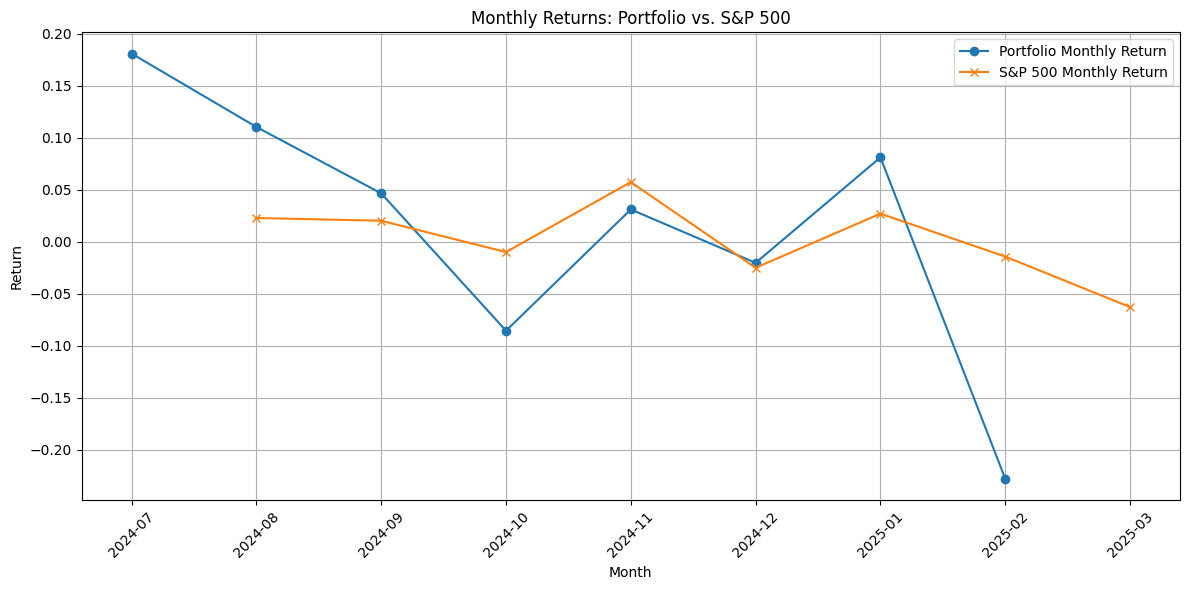

In [27]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# Define the test period (adjust these if needed)
test_start  = '2024-07-01'
test_end    = '2025-03-31'

def construct_portfolio_modified(pred_df, n_long=10, n_short=10):
    """Construct monthly long-short portfolio based on ensemble predictions,
    print long and short positions for each month, and save the selections."""
    print("Constructing portfolio selections (Modified)...")
    pred_df['date'] = pd.to_datetime(pred_df['date'])
    pred_df['year_month'] = pred_df['date'].dt.to_period('M')

    portfolio_list = []
    for period, group in pred_df.groupby('year_month'):
        # Apply fundamental filters:
        # Long: price > 200-day SMA, roe > 20%, debt_to_equity < 1
        group_long = group[(group['above_sma200'] == 1) & (group['roe'] > 0.20) & (group['debt_to_equity'] < 1)]
        # Short: price < 200-day SMA, roe < 10%, debt_to_equity > 2
        group_short = group[(group['above_sma200'] == 0) & (group['roe'] < 0.10) & (group['debt_to_equity'] > 2)]

        group_long_sorted = group_long.sort_values('ensemble_pred', ascending=False)
        group_short_sorted = group_short.sort_values('ensemble_pred', ascending=True)

        if len(group_long_sorted) < n_long or len(group_short_sorted) < n_short:
            print(f"Period {period}: Not enough candidates for long or short positions. Skipping.")
            continue

        long_stocks = group_long_sorted.head(n_long)[['ticker', 'date', 'ensemble_pred']]
        long_stocks['position'] = 'long'
        short_stocks = group_short_sorted.head(n_short)[['ticker', 'date', 'ensemble_pred']]
        short_stocks['position'] = 'short'

        month_portfolio = pd.concat([long_stocks, short_stocks])
        month_portfolio['year_month'] = period
        portfolio_list.append(month_portfolio)

    if not portfolio_list:
        raise ValueError("No valid portfolio selections could be made.")

    portfolio_df = pd.concat(portfolio_list, ignore_index=True)
    portfolio_df.to_csv('portfolio_selections.csv', index=False)
    print("Saved portfolio selections to portfolio_selections.csv")

    return portfolio_df

def backtest_portfolio_modified(price_data, portfolio_df):
    """Backtest the portfolio, print monthly returns, and plot them against S&P 500."""
    print("Backtesting portfolio (Modified)...")
    # Get price data for the test period
    price_data_test = price_data.loc[test_start:test_end]

    portfolio_df['date'] = pd.to_datetime(portfolio_df['date'])
    portfolio_df = portfolio_df[(portfolio_df['date'] >= test_start) & (portfolio_df['date'] <= test_end)]
    portfolio_df['year_month'] = portfolio_df['date'].dt.to_period('M')

    daily_returns = price_data_test.pct_change().dropna()
    monthly_returns = []

    for period, group in portfolio_df.groupby('year_month'):
        month_start = group['date'].min()
        month_end = month_start + pd.offsets.MonthEnd(0)
        if month_end > pd.to_datetime(test_end):
            month_end = pd.to_datetime(test_end)

        month_ret = daily_returns.loc[month_start:month_end]
        if month_ret.empty:
            continue

        # Get unique long and short tickers for the month
        long_tickers = group[group['position'] == 'long']['ticker'].unique().tolist()
        short_tickers = group[group['position'] == 'short']['ticker'].unique().tolist()

        # Print positions for this month
        print(f"\n{period} Positions:")
        print("Long:", long_tickers)
        print("Short:", short_tickers)

        # Calculate average returns for long and short sides
        long_returns = month_ret[long_tickers].mean(axis=1) if long_tickers else pd.Series()
        short_returns = month_ret[short_tickers].mean(axis=1) if short_tickers else pd.Series()
        if long_returns.empty or short_returns.empty:
            print(f"Skipping {period}: insufficient returns data.")
            continue

        long_cum_return = (1 + long_returns).cumprod().iloc[-1] - 1
        short_cum_return = (1 + short_returns).cumprod().iloc[-1] - 1
        portfolio_return = (long_cum_return - short_cum_return)

        print(f"{period} Monthly Return: {portfolio_return:.4f}")
        monthly_returns.append({
            'year_month': str(period),
            'long_return': long_cum_return,
            'short_return': short_cum_return,
            'portfolio_return': portfolio_return
        })

    returns_df = pd.DataFrame(monthly_returns)
    returns_df.to_csv('portfolio_returns.csv', index=False)
    print("Saved portfolio returns to portfolio_returns.csv")

    # Fetch S&P 500 monthly returns for the same period
    sp500 = yf.download('^GSPC', start=test_start, end=test_end, auto_adjust=True)['Close']
    sp500_monthly = sp500.resample('M').last().pct_change().dropna()
    sp500_monthly.index = sp500_monthly.index.to_period('M')

    # Plot portfolio vs. S&P 500 monthly returns
    plt.figure(figsize=(12,6))
    plt.plot(returns_df['year_month'], returns_df['portfolio_return'], marker='o', label='Portfolio Monthly Return')
    plt.plot(sp500_monthly.index.astype(str), sp500_monthly.values, marker='x', label='S&P 500 Monthly Return')
    plt.title('Monthly Returns: Portfolio vs. S&P 500')
    plt.xlabel('Month')
    plt.ylabel('Return')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    return returns_df

# --- Usage in Step 3 ---
# Assume pred_df and price_data are available from previous steps.
portfolio_df_mod = construct_portfolio_modified(pred_df, n_long=10, n_short=10)
returns_df_mod = backtest_portfolio_modified(price_data, portfolio_df_mod)


Part 4: Predict Next Month's Portfolio

In [29]:
def predict_portfolio(features_df, scaler, target_year=None, target_month=None, lookback_days=60):
    """
    Generate portfolio predictions for a specific target month.

    Args:
        features_df: Historical features dataframe
        scaler: The fitted StandardScaler
        target_year: Year to predict for (defaults to next month's year)
        target_month: Month to predict for (defaults to next month)
        lookback_days: Days to look back for latest features

    Returns:
        DataFrame with portfolio predictions
    """
    # Convert date column to datetime if needed
    if features_df['date'].dtype != 'datetime64[ns]':
        features_df['date'] = pd.to_datetime(features_df['date'])

    # Set default target date to next month if not specified
    if target_year is None or target_month is None:
        current_date = datetime.now()
        next_month = current_date.replace(day=1) + timedelta(days=32)
        next_month = next_month.replace(day=1)  # First day of next month

        if target_year is None:
            target_year = next_month.year
        if target_month is None:
            target_month = next_month.month

    target_date_str = f"{target_year}-{target_month:02d}-01"
    target_date = pd.to_datetime(target_date_str)
    print(f"Generating portfolio for {target_date.strftime('%B %Y')}")

    # Get the latest date in our features for lookback
    latest_date = features_df['date'].max()
    recent_df = features_df[features_df['date'] >=
                          (latest_date - timedelta(days=lookback_days))]

    # Find unique tickers with sufficient recent data
    tickers = recent_df['ticker'].unique().tolist()
    print(f"Found {len(tickers)} tickers with recent data")

    try:
        # Load models with error handling
        lr = joblib.load('lr_model.joblib')
        knn = joblib.load('knn_model.joblib')
        lstm = load_model('lstm_model.h5')

        # Feature columns (must match training)
        base_cols = ['sma_ratio', 'rsi', 'macd_hist', 'volatility', 'bb_width', 'roe', 'debt_to_equity',
                    'above_sma200', 'fund_long', 'fund_short', 'regime']
        arima_cols = [col for col in features_df.columns if col.startswith('arima_')]
        X_cols = base_cols + arima_cols

        # Get latest data point for each ticker
        latest_features = []
        valid_tickers = []

        for ticker in tickers:
            ticker_data = recent_df[recent_df['ticker'] == ticker]

            if len(ticker_data) < 10:  # Skip tickers with insufficient data
                continue

            # Get most recent data point
            ticker_latest = ticker_data.sort_values('date', ascending=False).iloc[0].copy()

            # Check fundamental criteria
            try:
                roe = float(ticker_latest['roe'])
                debt_equity = float(ticker_latest['debt_to_equity'])
                above_sma200 = int(ticker_latest['above_sma200'])

                # Apply strategy rules for filtering candidates
                # Long: price > SMA200, ROE > 20%, Debt/Equity < 1
                # Short: price < SMA200, ROE < 10%, Debt/Equity > 2
                if (above_sma200 == 1 and roe > 0.20 and debt_equity < 1) or \
                   (above_sma200 == 0 and roe < 0.10 and debt_equity > 2):

                    # Get feature values
                    features = [ticker_latest[col] for col in X_cols if col in ticker_latest]
                    if len(features) == len(X_cols):  # All required features present
                        latest_features.append(features)
                        valid_tickers.append(ticker)
            except Exception as e:
                continue  # Skip tickers with errors

        if not latest_features:
            print(f"No valid tickers found for {target_date.strftime('%B %Y')}")
            return None

        # Make predictions
        X_latest = np.array(latest_features)
        X_latest_scaled = scaler.transform(X_latest)

        # Get predictions from each model
        lr_preds = lr.predict(X_latest_scaled)
        knn_preds = knn.predict(X_latest_scaled)
        lstm_preds_prob = lstm.predict(X_latest_scaled.reshape(-1, 1, X_latest_scaled.shape[1]), verbose=0)
        lstm_preds = np.argmax(lstm_preds_prob, axis=1) - 1  # Convert from one-hot to (-1,0,1)

        # Create prediction results
        pred_results = pd.DataFrame({
            'ticker': valid_tickers,
            'lr_pred': lr_preds,
            'knn_pred': knn_preds,
            'lstm_pred': lstm_preds,
        })

        # Calculate ensemble score (average of all predictions)
        pred_results['ensemble_score'] = pred_results[['lr_pred', 'knn_pred', 'lstm_pred']].mean(axis=1)

        # Get the top 10 longs and shorts based on ensemble score
        longs = pred_results.sort_values('ensemble_score', ascending=False).head(10)
        shorts = pred_results.sort_values('ensemble_score', ascending=True).head(10)

        # Format for output
        longs['position'] = 'LONG'
        shorts['position'] = 'SHORT'
        portfolio = pd.concat([longs, shorts])
        portfolio['target_date'] = target_date
        portfolio['target_month'] = target_month
        portfolio['target_year'] = target_year

        # Save to CSV
        file_name = f"{target_date.strftime('%Y%m')}_portfolio.csv"
        portfolio.to_csv(file_name, index=False)
        print(f"Saved portfolio to {file_name}")

        return portfolio

    except Exception as e:
        print(f"Error generating portfolio: {e}")
        return None

def update_data_if_needed():
    """Update data if it's stale and return the latest features"""
    print("Checking if data needs updating...")

    try:
        # Load existing data
        price_data = pd.read_csv(price_data_path, index_col='Date', parse_dates=True)
        features_df = pd.read_csv(features_path)
        sp500_index = pd.read_csv(sp500_index_path, index_col='Date', parse_dates=True)

        # Remove duplicate indices
        if price_data.index.duplicated().any():
            price_data = price_data[~price_data.index.duplicated(keep='last')]
        if sp500_index.index.duplicated().any():
            sp500_index = sp500_index[~sp500_index.index.duplicated(keep='last')]

        # Check data freshness (7 days threshold)
        latest_date = price_data.index.max()
        current_date = datetime.now()

        if (current_date - latest_date).days > 7:
            print(f"Data is {(current_date - latest_date).days} days old. Updating...")
            current_tickers = features_df['ticker'].unique().tolist()

            # Download latest data
            new_prices = yf.download(current_tickers,
                                    start=latest_date,
                                    end=current_date + timedelta(days=1),
                                    auto_adjust=True, threads=True)['Close']

            new_sp500 = yf.download('^GSPC',
                                  start=latest_date,
                                  end=current_date + timedelta(days=1),
                                  auto_adjust=True)['Close']

            # Remove duplicates and merge with existing data
            if new_prices.index.duplicated().any():
                new_prices = new_prices[~new_prices.index.duplicated(keep='last')]
            if new_sp500.index.duplicated().any():
                new_sp500 = new_sp500[~new_sp500.index.duplicated(keep='last')]

            # Drop overlapping dates from original data
            price_data = price_data[~price_data.index.isin(new_prices.index)]
            sp500_index = sp500_index[~sp500_index.index.isin(new_sp500.index)]

            # Concatenate
            updated_prices = pd.concat([price_data, new_prices])
            updated_sp500 = pd.concat([sp500_index, new_sp500])

            # Save updated data
            updated_prices.to_csv('updated_' + price_data_path)
            updated_sp500.to_csv('updated_' + sp500_index_path)

            # Generate features
            updated_features = prepare_data(updated_prices, updated_sp500, current_tickers)
            return updated_features
        else:
            print("Data is recent. Using existing features.")
            return features_df
    except Exception as e:
        print(f"Error updating data: {e}")
        return features_df

def print_portfolio_summary(portfolio):
    """Print a summary of the portfolio predictions"""
    if portfolio is None or len(portfolio) == 0:
        print("No portfolio available.")
        return

    target_date = portfolio['target_date'].iloc[0]
    print(f"\n=== PORTFOLIO FOR {target_date.strftime('%B %Y').upper()} ===")

    # Print long positions
    print("\nLONG POSITIONS:")
    long_df = portfolio[portfolio['position'] == 'LONG'].sort_values('ensemble_score', ascending=False)
    for i, row in long_df.iterrows():
        print(f"{row['ticker']} (score: {row['ensemble_score']:.2f})")

    # Print short positions
    print("\nSHORT POSITIONS:")
    short_df = portfolio[portfolio['position'] == 'SHORT'].sort_values('ensemble_score', ascending=True)
    for i, row in short_df.iterrows():
        print(f"{row['ticker']} (score: {row['ensemble_score']:.2f})")

# --- Main execution ---
if __name__ == "__main__":

    # Load necessary data
    features_df = pd.read_csv(features_path)

    if not os.path.exists(scaler_path):
        scaler_path = '/content/drive/MyDrive/scaler.joblib'  # Assuming it's saved here

    scaler = joblib.load(scaler_path)

    # Update data if needed
    features_df = update_data_if_needed()

    # Generate portfolio
    portfolio = predict_portfolio(features_df, scaler, target_year=2025, target_month=4)

    # Print summary
    print_portfolio_summary(portfolio)
    # For specific month prediction (example for April 2025)
    # run_portfolio_prediction(year=2025, month=4)

Checking if data needs updating...


Error updating data: module 'datetime' has no attribute 'now'
Generating portfolio for April 2025
Found 428 tickers with recent data
Saved portfolio to 202504_portfolio.csv

=== PORTFOLIO FOR APRIL 2025 ===

LONG POSITIONS:
SWKS (score: 0.67)
CZR (score: 0.33)
CI (score: 0.33)
FIS (score: 0.33)
FRT (score: 0.33)
GM (score: 0.33)
DAY (score: 0.33)
HUM (score: 0.33)
KIM (score: 0.33)
IR (score: 0.33)

SHORT POSITIONS:
ALB (score: -0.33)
CRL (score: -0.33)
BEN (score: -0.33)
EXR (score: -0.33)
INTC (score: -0.33)
LHX (score: -0.33)
MCHP (score: -0.33)
J (score: -0.33)
RVTY (score: -0.33)
WY (score: -0.33)


Part 5: Performance Evaluation and Graphing

[*********************100%***********************]  1 of 1 completed

Evaluating portfolio performance...
Saved performance metrics to portfolio_performance.csv

Portfolio Performance Summary:
Total Return: 0.0582
Annualized Return: 0.0885
Annualized Volatility: 0.4390
Sharpe Ratio: 0.1560
Maximum Drawdown: -0.2287

Benchmark (S&P 500) Performance Summary:
Total Return: 0.0106
Annualized Return: 0.0160
Annualized Volatility: 0.1294
Sharpe Ratio: -0.0311
Maximum Drawdown: -0.0761

Strategy Outperformance vs. Benchmark:
Total Return: 0.0475 (better)
Annualized Return: 0.0725 (better)
Annualized Volatility: 0.3096 (worse)
Sharpe Ratio: 0.1872 (better)
Maximum Drawdown: -0.1526 (better)


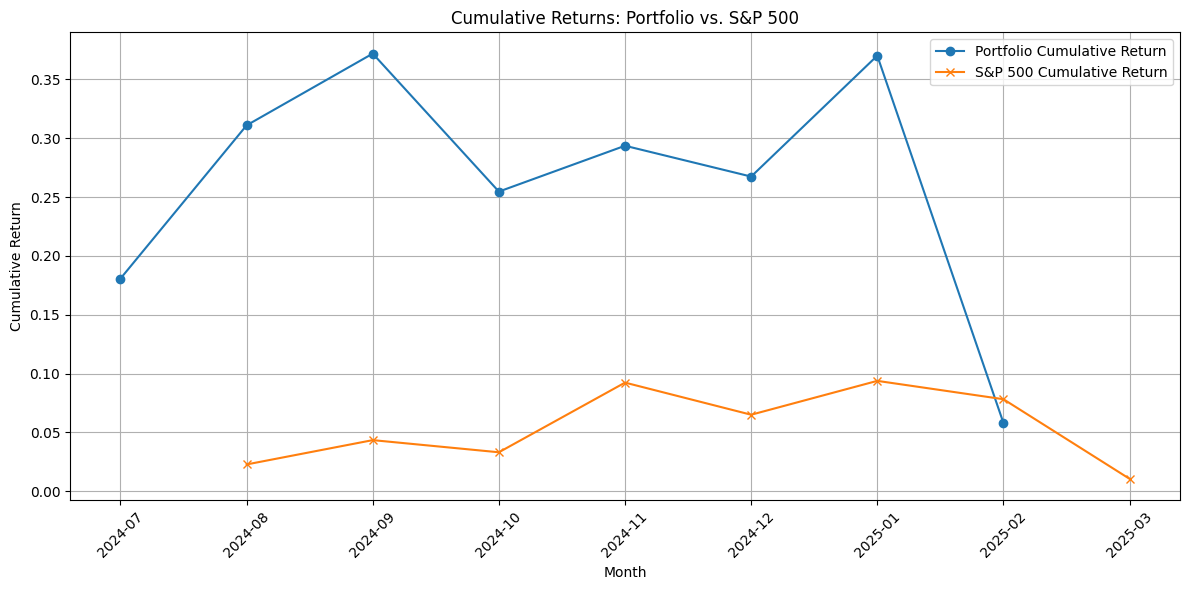

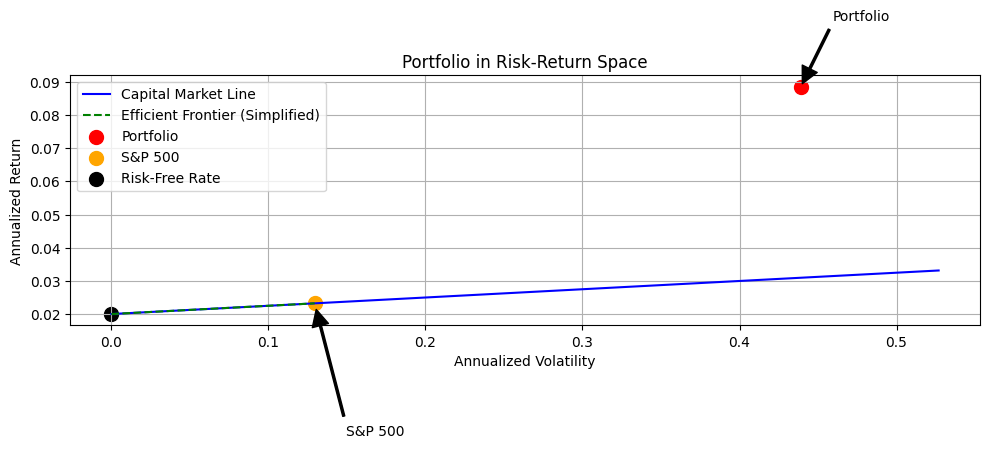

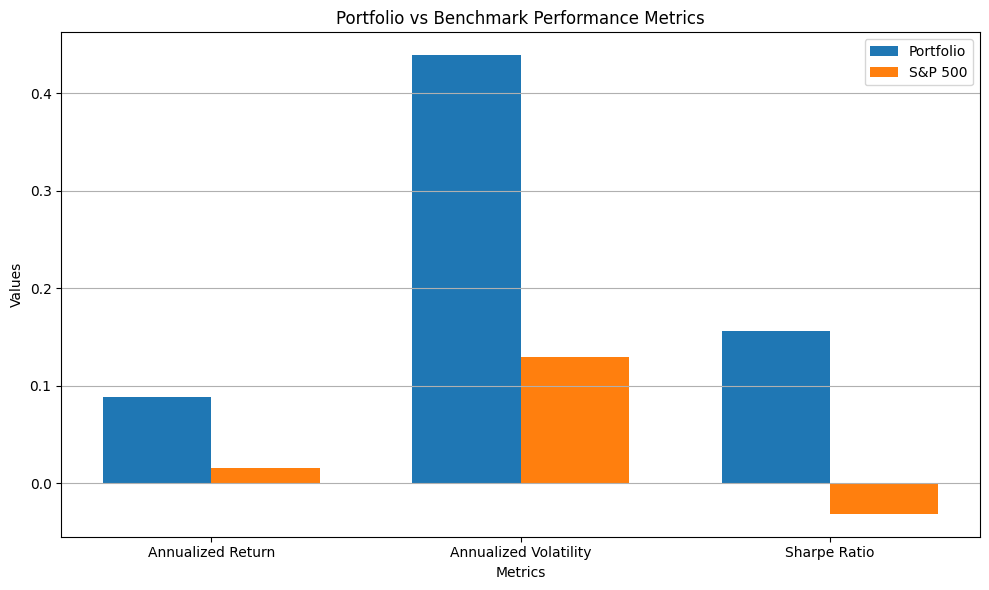

In [36]:
def evaluate_performance(returns_df, test_start, test_end, risk_free_rate=0.02):
    print("Evaluating portfolio performance...")
    returns_df['year_month'] = pd.to_datetime(returns_df['year_month'])
    returns_df = returns_df.sort_values('year_month')

    # Compute cumulative returns for portfolio
    returns_df['cumulative_return'] = (1 + returns_df['portfolio_return']).cumprod() - 1

    n_months = len(returns_df)
    total_return = returns_df['cumulative_return'].iloc[-1] if n_months > 0 else 0
    annualized_return = ((1 + total_return) ** (12 / n_months)) - 1 if n_months > 0 else 0
    monthly_vol = returns_df['portfolio_return'].std()
    annualized_vol = monthly_vol * np.sqrt(12) if monthly_vol is not None else 0
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_vol if annualized_vol != 0 else 0

    # Maximum drawdown calculation
    cumulative = (1 + returns_df['portfolio_return']).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    performance_metrics = {
        'Total Return': total_return,
        'Annualized Return': annualized_return,
        'Annualized Volatility': annualized_vol,
        'Sharpe Ratio': sharpe_ratio,
        'Maximum Drawdown': max_drawdown
    }

    perf_df = pd.DataFrame([performance_metrics])
    perf_df.to_csv('portfolio_performance.csv', index=False)
    print("Saved performance metrics to portfolio_performance.csv")

    print("\nPortfolio Performance Summary:")
    for key, value in performance_metrics.items():
        print(f"{key}: {value:.4f}")

    # --- Fetch and calculate S&P 500 performance ---
    # Fetch S&P 500 data for the test period
    sp500 = yf.download('^GSPC', start=test_start, end=test_end, auto_adjust=True)['Close']
    # Get month-end close prices
    sp500_monthly_close = sp500.resample('ME').last()
    # Calculate month-over-month returns
    sp500_monthly_returns = sp500_monthly_close.pct_change().dropna()
    # Compute cumulative returns from these monthly returns
    sp500_monthly_cum = (1 + sp500_monthly_returns).cumprod() - 1

    # Calculate benchmark performance metrics
    benchmark_n_months = len(sp500_monthly_returns)
    benchmark_total_return = float(sp500_monthly_cum.iloc[-1]) if benchmark_n_months > 0 else 0
    benchmark_annualized_return = ((1 + benchmark_total_return) ** (12 / benchmark_n_months)) - 1 if benchmark_n_months > 0 else 0
    benchmark_monthly_vol = float(sp500_monthly_returns.std())
    benchmark_annualized_vol = benchmark_monthly_vol * np.sqrt(12) if benchmark_monthly_vol is not None else 0
    benchmark_sharpe_ratio = (benchmark_annualized_return - risk_free_rate) / benchmark_annualized_vol if benchmark_annualized_vol != 0 else 0

    # Benchmark Maximum drawdown calculation
    benchmark_cumulative = (1 + sp500_monthly_returns).cumprod()
    benchmark_rolling_max = benchmark_cumulative.cummax()
    benchmark_drawdown = (benchmark_cumulative - benchmark_rolling_max) / benchmark_rolling_max
    benchmark_max_drawdown = float(benchmark_drawdown.min())

    benchmark_metrics = {
        'Total Return': benchmark_total_return,
        'Annualized Return': benchmark_annualized_return,
        'Annualized Volatility': benchmark_annualized_vol,
        'Sharpe Ratio': benchmark_sharpe_ratio,
        'Maximum Drawdown': benchmark_max_drawdown
    }

    # Save benchmark metrics
    benchmark_df = pd.DataFrame([benchmark_metrics])
    benchmark_df.to_csv('benchmark_performance.csv', index=False)

    print("\nBenchmark (S&P 500) Performance Summary:")
    for key, value in benchmark_metrics.items():
        print(f"{key}: {value:.4f}")

    # Calculate outperformance metrics
    outperformance = {
        'Total Return': total_return - benchmark_total_return,
        'Annualized Return': annualized_return - benchmark_annualized_return,
        'Annualized Volatility': annualized_vol - benchmark_annualized_vol,
        'Sharpe Ratio': sharpe_ratio - benchmark_sharpe_ratio,
        'Maximum Drawdown': max_drawdown - benchmark_max_drawdown
    }

    print("\nStrategy Outperformance vs. Benchmark:")
    for key, value in outperformance.items():
        print(f"{key}: {value:.4f}" + (" (better)" if (key != 'Annualized Volatility' and key != 'Maximum Drawdown' and value > 0) or
                                        ((key == 'Annualized Volatility' or key == 'Maximum Drawdown') and value < 0) else " (worse)"))

    # Plot cumulative returns vs. S&P 500
    returns_df_plot = returns_df.copy()
    date_strings = returns_df_plot['year_month'].dt.strftime('%Y-%m')
    sp500_date_strings = sp500_monthly_cum.index.strftime('%Y-%m')

    plt.figure(figsize=(12,6))
    plt.plot(date_strings, returns_df_plot['cumulative_return'], marker='o', label='Portfolio Cumulative Return')
    plt.plot(sp500_date_strings, sp500_monthly_cum.values, marker='x', label='S&P 500 Cumulative Return')

    plt.title('Cumulative Returns: Portfolio vs. S&P 500')
    plt.xlabel('Month')
    plt.ylabel('Cumulative Return')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig('cumulative_returns_comparison.png')
    plt.show()

    # Compute Capital Market Line (CML) and a simplified Efficient Frontier
    # Use the monthly returns from the S&P 500
    market_return = float(sp500_monthly_returns.mean() * 12)
    market_vol = float(sp500_monthly_returns.std() * np.sqrt(12))
    cml_slope = (market_return - risk_free_rate) / market_vol if market_vol != 0 else 0
    cml_vols = np.linspace(0, max(annualized_vol, market_vol) * 1.2, 100)
    cml_returns = risk_free_rate + cml_slope * cml_vols

    eff_vols = np.linspace(0, market_vol, 100)
    eff_returns = risk_free_rate + (market_return - risk_free_rate) * (eff_vols / market_vol)

    plt.figure(figsize=(10,6))
    plt.plot(cml_vols, cml_returns, label='Capital Market Line', color='blue')
    plt.plot(eff_vols, eff_returns, label='Efficient Frontier (Simplified)', color='green', linestyle='--')
    plt.scatter([annualized_vol], [annualized_return], color='red', s=100, label='Portfolio')
    plt.scatter([market_vol], [market_return], color='orange', s=100, label='S&P 500')
    plt.scatter([0], [risk_free_rate], color='black', s=100, label='Risk-Free Rate')

    # Add annotations
    plt.annotate('Portfolio', xy=(annualized_vol, annualized_return),
                 xytext=(annualized_vol+0.02, annualized_return+0.02),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5))
    plt.annotate('S&P 500', xy=(market_vol, market_return),
                 xytext=(market_vol+0.02, market_return-0.04),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5))

    plt.title('Portfolio in Risk-Return Space')
    plt.xlabel('Annualized Volatility')
    plt.ylabel('Annualized Return')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig('risk_return_analysis.png')
    plt.show()

    # Add comparison bar chart
    metrics_to_compare = ['Annualized Return', 'Annualized Volatility', 'Sharpe Ratio']
    portfolio_values = [performance_metrics[m] for m in metrics_to_compare]
    benchmark_values = [benchmark_metrics[m] for m in metrics_to_compare]

    plt.figure(figsize=(10, 6))
    x = np.arange(len(metrics_to_compare))
    width = 0.35

    plt.bar(x - width/2, portfolio_values, width, label='Portfolio')
    plt.bar(x + width/2, benchmark_values, width, label='S&P 500')

    plt.xlabel('Metrics')
    plt.ylabel('Values')
    plt.title('Portfolio vs Benchmark Performance Metrics')
    plt.xticks(x, metrics_to_compare)
    plt.legend()
    plt.grid(axis='y')
    plt.tight_layout()
    plt.savefig('performance_comparison.png')
    plt.show()

    return returns_df, performance_metrics, benchmark_metrics

# --- Usage in Step 5 ---
returns_df_final, performance_metrics_final, benchmark_metrics_final = evaluate_performance(returns_df_mod, test_start, test_end)